# LA County Community Health Profiles: Education and Self-Rated Health

This notebook explores how educational attainment, income and poverty relate to the percentage of adults reporting fair or poor health across LA County communities. The data come from the LA County Community Health Profiles (Theme 2: Social Determinants of Health). The analysis is exploratory: it describes associations and does not establish cause and effect.

## 1. Research Questions

### Primary analysis: incorporated cities
1. Which measures of educational attainment among adults 25 and older (less than high school, high school graduate, some college, bachelor's degree or higher) are most strongly associated with the percentage of adults reporting fair or poor health across LA County incorporated cities?
2. Does the relationship persist after accounting for differences in median household income and poverty (below 100% and 200% of the Federal Poverty Level)?

### Secondary analysis: Los Angeles City neighborhoods
3. Do the same education measures show similar associations with fair or poor self-rated health across Los Angeles City neighborhoods?
4. Are the strength and direction of these associations, before and after accounting for income and poverty, consistent between the neighborhood analysis and the incorporated-city analysis?

## 2. Data Dictionary

Only the columns used in this analysis are listed.

**Identifiers**
- `Geo_ID`: Short geography ID code, such as `la_county` or `spa_1`.
- `Geography_Name`: The display name of the geography.
- `Geography_Type`: The category of geography (neighborhood, incorporated city, SPA, council district, etc.).

**Outcome**
- `Poor_health`: Percentage of adults 18 and older who report fair or poor health (2023 LA County Health Survey).
- `Poor_health_EST`: Estimation method for `Poor_health`, either direct estimate or small area estimate.

**Education predictors (adults 25 and older)**
- `Edu_LessHS_Pct`: Percentage of adults with less than a high school education.
- `Edu_HSGrad_Pct`: Percentage of adults whose highest attainment is a high school diploma or equivalent.
- `Edu_College_Pct`: Percentage of adults with some college or an associate's degree, without a bachelor's.
- `Edu_Bach_Pct`: Percentage of adults with a bachelor's degree or higher.

**Income and poverty (for questions 2 and 4)**
- `MHI`: Median household income in 2022 inflation-adjusted dollars. For each geography it is a population-weighted average of tract-level medians.
- `100_FPL_Pct`: Percentage of the total population (children and adults) living below 100% of the Federal Poverty Level.
- `200_FPL_Pct`: Percentage of the total population living below 200% of the Federal Poverty Level.

## 3. Load and Inspect the Data

### 3.1 Setup and load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\pinks\Downloads\Community_Health_Profiles_-_Data_Download\CSV CHP Theme 2 - Social Determinants of Health - Data.csv")

### 3.2 First look at the data

In [3]:
# Output First Five Rows
df.head()

,#,Geo_ID,Geo_Feature,Geography_Name,Geography_Type,LE_birth,LE_birth_LCL,LE_birth_UCL,Overall_MR,Overall_MR_LCL,...,Diff_Child_C_LCL,Diff_Child_C_UCL,Diff_Child_C_EST,Voting,Voting_LCL,Voting_UCL,SE_Support,SE_Support_LCL,SE_Support_UCL,SE_Support_EST
0,0,hp_target,Healthy People 2030 Target,Healthy People 2030 Target,Healthy People 2030 Target,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,la_county,Los Angeles County,Los Angeles County,County,80.4,80.3,80.5,668.8,664.0,...,35.3,42.3,direct estimate,73.1,73.1,73.1,61.8,60.4,63.1,direct estimate
2,2,spa_1,SPA 1,SPA 1: Antelope Valley,Service Planning Area,75.9,75.4,76.4,905.7,875.1,...,33.1,56.8,direct estimate,70.6,70.4,70.8,59.7,54.1,65.4,direct estimate
3,3,spa_2,SPA 2,SPA 2: San Fernando,Service Planning Area,81.0,80.8,81.2,651.1,641.1,...,23.2,38.5,direct estimate,75.7,75.6,75.8,65.2,61.9,68.6,direct estimate
4,4,spa_3,SPA 3,SPA 3: San Gabriel,Service Planning Area,81.3,81.0,81.5,636.1,625.6,...,31.8,46.2,direct estimate,75.6,75.5,75.7,61.8,58.9,64.6,direct estimate


### 3.3 Missing values

This check runs on the full dataset, before any rows are filtered. Missing values in the analysis datasets are checked in sections 6 and 7.

In [76]:
# Check for Missing Data Within Columns Relevant to Research Questions
analysis_cols = ["Geo_ID", "Geography_Name", "Geography_Type",
        "Poor_health", "Poor_health_EST",
        "Edu_LessHS_Pct", "Edu_HSGrad_Pct", "Edu_College_Pct", "Edu_Bach_Pct",
        "MHI", "100_FPL_Pct", "200_FPL_Pct"]

missing = df.loc[:, analysis_cols].isna().sum()

pd.DataFrame({
    "Missing": missing,
    "Missing %": (missing / len(df) * 100).round(1)
}).query("Missing > 0").sort_values(by="Missing", ascending=False)

,Missing,Missing %
Edu_LessHS_Pct,3,1.6
Poor_health,1,0.5
Poor_health_EST,1,0.5
Edu_HSGrad_Pct,1,0.5
Edu_College_Pct,1,0.5
Edu_Bach_Pct,1,0.5
MHI,1,0.5
200_FPL_Pct,1,0.5


### 3.4 Geography types and estimation method

The first row is the Healthy People 2030 target, which is a benchmark and not a geography, so `df[1:]` is used for the counts below. The `#` column is only a row index and is not needed for the analysis.

In [114]:
df["Poor_health_EST"].value_counts()

Poor_health_EST
small area estimate    167
direct estimate         14
Name: count, dtype: int64

Geography_Type
Los Angeles City Neighborhood        74
Incorporated City                    64
Los Angeles City Council District    15
Unincorporated Los Angeles County    14
Service Planning Area                 8
Supervisorial District                5
County                                1
Name: count, dtype: int64


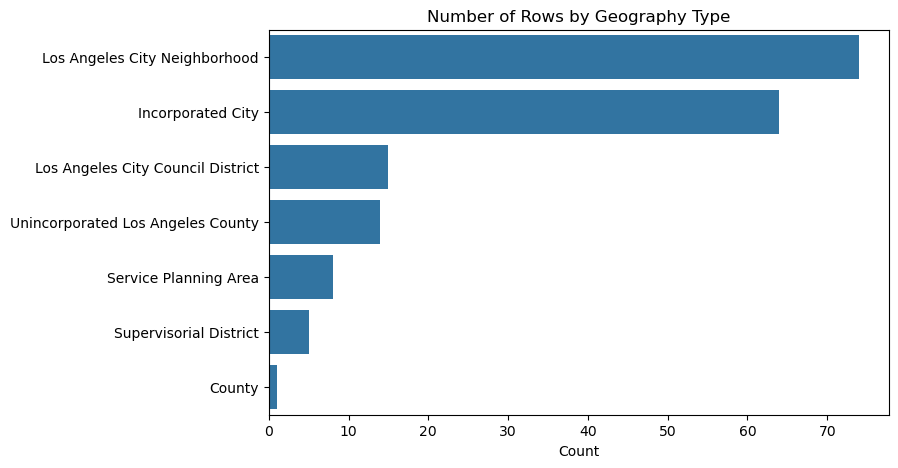

Geography_Type
County                               13.700000
Incorporated City                    12.131250
Los Angeles City Council District    14.360000
Los Angeles City Neighborhood        14.655405
Service Planning Area                13.850000
Supervisorial District               13.880000
Unincorporated Los Angeles County    12.471429
Name: Poor_health, dtype: float64



Poor_health_EST,direct estimate,small area estimate
Geography_Type,,
County,1,0
Incorporated City,0,64
Los Angeles City Council District,0,15
Los Angeles City Neighborhood,0,74
Service Planning Area,8,0
Supervisorial District,5,0
Unincorporated Los Angeles County,0,14


In [127]:
# Counts of Geography Types
print(df[1:]["Geography_Type"].value_counts())

# Graph Counts
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df[1:], 
    y="Geography_Type", 
    order=df[1:]["Geography_Type"].value_counts().index
)
plt.title("Number of Rows by Geography Type")
plt.xlabel("Count")
plt.ylabel("")
plt.show()

# Average Self-Reported Health by Geography Type
print(df[1:].groupby("Geography_Type")["Poor_health"].mean())

# Poor Health Estimates by Geography Type
print()
pd.crosstab(df[1:]["Geography_Type"], df[1:]["Poor_health_EST"])

**Takeaway:** The estimation method follows geography type. The county, service planning areas and supervisorial districts use direct estimates, while cities, neighborhoods, council districts and unincorporated areas use small area estimates. Both analysis datasets therefore contain only small area estimates.

## 4. Geography Structure and Overlap

Rows in this dataset describe the same people at different geographic scales. For example, the county contains every other geography. Analyzing overlapping rows together would count residents more than once and distort correlations. Each overlap below is tested by comparing summed population counts (the `_Pop` columns).

### 4.1 City of Los Angeles, neighborhoods and council districts

In [35]:
# Los Angeles is Included in Incorporated Cities
incorporated_city_name = df.loc[df["Geography_Type"] == "Incorporated City"]["Geography_Name"]

print(f"Los Angeles City Included in Incorporated Cities: {incorporated_city_name[incorporated_city_name.str.contains("Los Angeles", case=False)].tolist()}")

# Compare Population Counts of Los Angeles Neighborhoods, Los Angeles City, and Los Angeles City Council Districts
pop_columns = df.columns[df.columns.str.endswith("_Pop")]

la_city = df.loc[df["Geography_Name"] == "City of Los Angeles"]
la_neighborhood = df.loc[df["Geography_Type"] == "Los Angeles City Neighborhood"]
la_council = df.loc[df["Geography_Type"] == "Los Angeles City Council District"]

pd.DataFrame({
        "Los Angeles City": la_city[pop_columns].sum(),
        "Los Angeles Neighborhood": la_neighborhood[pop_columns].sum(),
        "Los Angeles City Council Districts": la_council[pop_columns].sum(),
        "Neighborhoods % of City": (la_neighborhood[pop_columns].sum() / la_city[pop_columns].sum() * 100).round(2),
        "City Council % of City": (la_council[pop_columns].sum() / la_city[pop_columns].sum() * 100).round(2)
    })

Los Angeles City Included in Incorporated Cities: ['City of Los Angeles']


,Los Angeles City,Los Angeles Neighborhood,Los Angeles City Council Districts,Neighborhoods % of City,City Council % of City
100_FPL_Pop,625833.0,554402.0,625833.0,88.59,100.00
200_FPL_Pop,1402362.0,1244814.0,1402362.0,88.77,100.00
100_FPL_Child_Pop,169904.0,153778.0,169904.0,90.51,100.00
200_FPL_Child_Pop,365374.0,329769.0,365374.0,90.26,100.00
Edu_LessHS_Pop,581641.0,522251.0,581872.0,89.79,100.04
Edu_HSGrad_Pop,512122.0,448213.0,512451.0,87.52,100.06
Edu_College_Pop,634995.0,542629.0,635379.0,85.45,100.06
Edu_Bach_Pop,1002780.0,820488.0,1003617.0,81.82,100.08


**Finding:** `City of Los Angeles` appears among the incorporated cities. The 15 council districts add up to essentially 100% of the city's counts, so they duplicate the city row. The 74 neighborhoods add up to roughly 82% to 90% of the city's counts, so they overlap with most, but not all, of the city.

**Decision:** Drop the council districts. Keep the `City of Los Angeles` row in the primary analysis so the city is fully covered, and analyze the neighborhoods separately in the secondary analysis, since they leave out roughly 10% to 18% of the city's population.

### 4.2 County, supervisorial districts and service planning areas

In [34]:
pop_columns = df.columns[df.columns.str.endswith("_Pop")]

la_county = df.loc[df["Geography_Type"] == "County"]
supervisorial = df.loc[df["Geography_Type"] == "Supervisorial District"]
service_plan = df.loc[df["Geography_Type"] == "Service Planning Area"]

pd.DataFrame({
    "Los Angeles County": la_county[pop_columns].sum(),
    "Supervisorial Districts": supervisorial[pop_columns].sum(),
    "Service Planning Area": service_plan[pop_columns].sum(),
    "Supervisorial Districts % of County": (supervisorial[pop_columns].sum() / la_county[pop_columns].sum() * 100).round(2),
    "Service Planning Area % of County": (service_plan[pop_columns].sum() / la_county[pop_columns].sum() * 100).round(2)
})

,Los Angeles County,Supervisoral Districts,Service Planning Area,Supervisorial Districts % of City,Service Planning Area % of City
100_FPL_Pop,1352167.0,1352167.0,1352167.0,100.0,100.0
200_FPL_Pop,3093515.0,3093515.0,3093515.0,100.0,100.0
100_FPL_Child_Pop,381427.0,381427.0,381427.0,100.0,100.0
200_FPL_Child_Pop,853786.0,853786.0,853786.0,100.0,100.0
Edu_LessHS_Pop,1364653.0,1364653.0,1364653.0,100.0,100.0
Edu_HSGrad_Pop,1412260.0,1412260.0,1412260.0,100.0,100.0
Edu_College_Pop,1743178.0,1743178.0,1743178.0,100.0,100.0
Edu_Bach_Pop,2389559.0,2389559.0,2389559.0,100.0,100.0


**Finding:** The supervisorial districts and the service planning areas each add up to 100% of the county totals, so each set duplicates the county row.

**Decision:** Drop the county, supervisorial districts and service planning areas.

### 4.3 Incorporated cities and unincorporated areas

In [36]:
pop_columns = df.columns[df.columns.str.endswith("_Pop")]

la_county = df.loc[df["Geography_Type"] == "County"]
incorporated_city = df.loc[df["Geography_Type"] == "Incorporated City"]
unincorporated_city = df.loc[df["Geography_Type"] == "Unincorporated Los Angeles County"]

pd.DataFrame({
    "Los Angeles County": la_county[pop_columns].sum(),
    "Incorporated Cities": incorporated_city[pop_columns].sum(),
    "Unincorporated Cities": unincorporated_city[pop_columns].sum(),
    "Incorporated and Unincorporated % of County": ((incorporated_city[pop_columns].sum() + unincorporated_city[pop_columns].sum()) / la_county[pop_columns].sum() * 100).round(2) 
})

,Los Angeles County,Incorporated Cities,Unincorporated Cities,Incorporated and Unincorporated % of County
100_FPL_Pop,1352167.0,1212023.0,78932.0,95.47
200_FPL_Pop,3093515.0,2757860.0,189217.0,95.27
100_FPL_Child_Pop,381427.0,337327.0,26538.0,95.40
200_FPL_Child_Pop,853786.0,750567.0,61450.0,95.11
Edu_LessHS_Pop,1364653.0,1181070.0,105168.0,94.25
Edu_HSGrad_Pop,1412260.0,1226272.0,98918.0,93.83
Edu_College_Pop,1743178.0,1524662.0,105196.0,93.50
Edu_Bach_Pop,2389559.0,2114430.0,103468.0,92.82


**Finding:** Incorporated cities and unincorporated areas together account for roughly 93% to 96% of the county totals, so some communities in the county are not in these rows. A likely reason is that smaller communities are not profiled, but this has not been confirmed against the dataset documentation.

**Decision:** Keep both groups, and record the coverage gap as a limitation (section 9).

## 5. Build the Analysis Datasets

### 5.1 Drop rows that duplicate other rows

In [93]:
# Drop the Unnecessary Data
overlap_types = ["Healthy People 2030 Target", "County", "Los Angeles City Council District", "Service Planning Area", "Supervisorial District"]

base = df.loc[~df["Geography_Type"].isin(overlap_types)]

### 5.2 Keep only the columns used in the analysis

In [94]:
# Identify Columns Needed for Analysis
analysis_cols = ["Geo_ID", "Geography_Name", "Geography_Type",
        "Poor_health", "Poor_health_EST",
        "Edu_LessHS_Pct", "Edu_HSGrad_Pct", "Edu_College_Pct", "Edu_Bach_Pct",
        "MHI", "100_FPL_Pct", "200_FPL_Pct"]
base = base[analysis_cols]

# Check First Five Rows
base.head()

,Geo_ID,Geography_Name,Geography_Type,Poor_health,Poor_health_EST,Edu_LessHS_Pct,Edu_HSGrad_Pct,Edu_College_Pct,Edu_Bach_Pct,MHI,100_FPL_Pct,200_FPL_Pct
15,csa_city_alhambra,City of Alhambra,Incorporated City,14.9,small area estimate,16.9,21.3,23.4,38.4,80234.0,12.2,28.3
16,csa_city_arcadia,City of Arcadia,Incorporated City,11.2,small area estimate,7.3,17.2,20.6,54.9,108214.0,8.0,18.2
17,csa_city_azusa,City of Azusa,Incorporated City,14.3,small area estimate,20.0,24.6,28.7,26.8,81516.0,12.8,31.0
18,csa_city_baldwin_park,City of Baldwin Park,Incorporated City,15.5,small area estimate,33.0,29.8,23.1,14.1,76002.0,12.7,30.8
19,csa_city_bell,City of Bell,Incorporated City,17.2,small area estimate,42.3,30.1,18.8,8.8,56685.0,21.9,54.4


### 5.3 Split into primary and secondary datasets

- `df_cities`: incorporated cities (including the City of Los Angeles) and unincorporated areas.
- `df_neighborhoods`: Los Angeles City neighborhoods.

The row counts of both datasets are printed below.

In [128]:
# Create Separate Datasets for Primary and Secondary Analysis
df_cities = base.loc[base["Geography_Type"].isin(["Incorporated City", "Unincorporated Los Angeles County"])]
df_neighborhoods = base.loc[base["Geography_Type"] == "Los Angeles City Neighborhood"]

# Change Shape of Both Datasets
print(df_cities.shape, df_neighborhoods.shape)

(78, 12) (74, 12)


### 5.4 Reusable EDA functions

Each function takes a dataset and a label, so both analyses run through the same steps and every title says which dataset it shows.

In [ ]:
EDU_COLS = ["Edu_LessHS_Pct", "Edu_HSGrad_Pct", "Edu_College_Pct", "Edu_Bach_Pct"]


def summarize_data(data, label=""):
    print(f"--- {label} (n={len(data)}) ---")
    print(data.select_dtypes("number").describe().round(2))


def plot_distributions(data, label=""):
    num_cols = data.select_dtypes("number").columns
    nrows = (len(num_cols) + 1) // 2

    fig, axes = plt.subplots(nrows, 2, figsize=(12, 3.5 * nrows))
    for ax, col in zip(axes.flat, num_cols):
        sns.histplot(data=data, x=col, kde=True, ax=ax)
        ax.set_title(f"Distribution of {col}")
        ax.set_ylabel("Count")
    for ax in axes.flat[len(num_cols):]:
        ax.set_visible(False)

    fig.suptitle(f"Distributions: {label}")
    plt.tight_layout()
    plt.show()


def plot_correlations(data, label=""):
    corr = data.select_dtypes("number").corr()

    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(f"Correlations: {label}")
    plt.tight_layout()
    plt.show()
    return corr


def plot_edu_scatter(data, label=""):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    for ax, col in zip(axes.flat, EDU_COLS):
        sns.regplot(data=data, x=col, y="Poor_health", ax=ax,
                    scatter_kws={"alpha": 0.6})
        ax.set_title(f"Poor Health vs {col}")
        ax.set_ylabel("Poor Health (%)")

    fig.suptitle(f"Poor Health vs Education: {label}")
    plt.tight_layout()
    plt.show()

## 6. EDA: Cities (Primary Analysis)

This section runs the four EDA steps on `df_cities` to address questions 1 and 2.

### 6.1 Summary statistics

In [ ]:
summarize_data(df_cities, "Cities")

### 6.2 Distributions

In [ ]:
plot_distributions(df_cities, "Cities")

### 6.3 Correlations

In [ ]:
corr_cities = plot_correlations(df_cities, "Cities")

### 6.4 Education and poor health

In [ ]:
plot_edu_scatter(df_cities, "Cities")

**Takeaway:** _Write 2 to 3 sentences on what the summary statistics, distributions, correlations and scatterplots show for cities._

## 7. EDA: Neighborhoods (Secondary Analysis)

This section repeats the same steps on `df_neighborhoods` to address questions 3 and 4. The neighborhoods cover roughly 82% to 90% of the City of Los Angeles, not all of it.

### 7.1 Summary statistics

In [ ]:
summarize_data(df_neighborhoods, "LA City Neighborhoods")

### 7.2 Distributions

In [ ]:
plot_distributions(df_neighborhoods, "LA City Neighborhoods")

### 7.3 Correlations

In [ ]:
corr_neighborhoods = plot_correlations(df_neighborhoods, "LA City Neighborhoods")

### 7.4 Education and poor health

In [ ]:
plot_edu_scatter(df_neighborhoods, "LA City Neighborhoods")

**Takeaway:** _Write 2 to 3 sentences on what the summary statistics, distributions, correlations and scatterplots show for la city neighborhoods._

## 8. Findings

_Complete this section after reviewing sections 6 and 7. Answer each question directly and cite the supporting numbers._

**Question 1:** Which education measures are most strongly associated with fair or poor health among cities?

_Answer:_

**Question 2:** Does the relationship persist after accounting for income and poverty?

_Answer:_

**Question 3:** Do the same education measures show similar associations among neighborhoods?

_Answer:_

**Question 4:** Are the associations consistent between the neighborhood and city analyses?

_Answer:_

## 9. Limitations

- **Modeled outcome.** `Poor_health` for cities, neighborhoods and unincorporated areas is a small area estimate, not a direct survey measure. If the model uses Census characteristics as inputs, some of the associations found here may reflect the modeling itself.
- **Incomplete coverage.** The neighborhoods cover roughly 82% to 90% of the City of Los Angeles, and incorporated cities plus unincorporated areas cover roughly 93% to 96% of the county. Some communities are not in the data.
- **Ecological data.** Each row is a geography, not a person, so associations describe communities and do not necessarily apply to individuals. Correlation does not establish causation.
- **Small samples and overlapping predictors.** Each dataset has under 100 rows. The four education measures describe the same population and are mutually exclusive, and education, income and poverty are strongly correlated with each other, which makes their separate contributions hard to distinguish.
- **Missing values.** `Edu_LessHS_Pct` is missing for one row in each dataset. Correlations and trend lines skip these rows automatically.